<a href="https://colab.research.google.com/github/EcTrailblazers/python-data-projects/blob/main/16_gsec_yield_curve_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import CubicSpline

# Yields (%) across sovereign tenors (in Years)
# Regime A: Monetary Tightening / Inflation Surge (Flat / Inverted Pressure)
# Regime B: Monetary Normalization / Rate Cuts Anticipated (Upward Sloping / Steep)
gsec_market_data = """Tenor_Years,Tenor_Label,Yield_Hiking_Regime_%,Yield_Easing_Regime_%
0.25,91D T-Bill,6.85,6.15
0.50,182D T-Bill,7.05,6.30
1.00,1Y G-Sec,7.18,6.42
2.00,2Y G-Sec,7.22,6.58
3.00,3Y G-Sec,7.25,6.72
5.00,5Y G-Sec,7.28,6.90
7.00,7Y G-Sec,7.31,7.02
10.00,10Y Benchmark,7.34,7.12
14.00,14Y G-Sec,7.40,7.24
30.00,30Y Long Bond,7.52,7.38
"""

with open("gsec_yield_data.csv", "w") as f:
    f.write(gsec_market_data.strip())

print("gsec_yield_data.csv created successfully.")

gsec_yield_data.csv created successfully.


In [2]:
df_gsec = pd.read_csv("gsec_yield_data.csv")

# Known market maturity points
x_tenors = df_gsec["Tenor_Years"].values
y_tight = df_gsec["Yield_Hiking_Regime_%"].values
y_easy = df_gsec["Yield_Easing_Regime_%"].values

# Fit Cubic Splines
cs_tight = CubicSpline(x_tenors, y_tight)
cs_easy = CubicSpline(x_tenors, y_easy)

# Generate dense continuous maturities from 3 months to 30 years
dense_tenors = np.linspace(0.25, 30.0, 300)
curve_tight_dense = cs_tight(dense_tenors)
curve_easy_dense = cs_easy(dense_tenors)

print("Cubic Spline models fitted successfully across continuous maturity space.")

Cubic Spline models fitted successfully across continuous maturity space.


In [3]:
# 1. Term Spread (10Y - 2Y)
spread_tight_10_2 = (
    df_gsec.loc[df_gsec["Tenor_Years"] == 10.0, "Yield_Hiking_Regime_%"].values[0]
    - df_gsec.loc[df_gsec["Tenor_Years"] == 2.0, "Yield_Hiking_Regime_%"].values[0]
) * 100

spread_easy_10_2 = (
    df_gsec.loc[df_gsec["Tenor_Years"] == 10.0, "Yield_Easing_Regime_%"].values[0]
    - df_gsec.loc[df_gsec["Tenor_Years"] == 2.0, "Yield_Easing_Regime_%"].values[0]
) * 100

# 2. Curvature (2*5Y - [2Y + 10Y])
curv_tight = (
    2 * df_gsec.loc[df_gsec["Tenor_Years"] == 5.0, "Yield_Hiking_Regime_%"].values[0]
    - (
        df_gsec.loc[df_gsec["Tenor_Years"] == 2.0, "Yield_Hiking_Regime_%"].values[0]
        + df_gsec.loc[df_gsec["Tenor_Years"] == 10.0, "Yield_Hiking_Regime_%"].values[0]
    )
) * 100

curv_easy = (
    2 * df_gsec.loc[df_gsec["Tenor_Years"] == 5.0, "Yield_Easing_Regime_%"].values[0]
    - (
        df_gsec.loc[df_gsec["Tenor_Years"] == 2.0, "Yield_Easing_Regime_%"].values[0]
        + df_gsec.loc[df_gsec["Tenor_Years"] == 10.0, "Yield_Easing_Regime_%"].values[0]
    )
) * 100

# 3. Bond Duration & DV01 on a ₹100 Cr Portfolio for Par Bonds
# Modified Duration approximation for par bond: D_mod ≈ (1 - (1 + y/2)^(-2T)) / y
y_par = df_gsec["Yield_Easing_Regime_%"] / 100
t_mat = df_gsec["Tenor_Years"]
df_gsec["Mod_Duration_Years"] = (1 - (1 + y_par / 2) ** (-2 * t_mat)) / y_par
df_gsec["DV01_per_100Cr_Rupees"] = (
    df_gsec["Mod_Duration_Years"] * 0.0001 * 100_00_00_000
)

print("--- Term Structure Diagnostics ---")
print(f"Hiking Regime 10Y-2Y Slope: {spread_tight_10_2:.1f} bps (Flattened)")
print(f"Easing Regime 10Y-2Y Slope: {spread_easy_10_2:.1f} bps (Normal Steepness)")
print(f"Hiking Regime Curvature:   {curv_tight:.1f} bps")
print(f"Easing Regime Curvature:   {curv_easy:.1f} bps\n")

print("--- Bond Portfolio Sensitivity Table (₹100 Cr Exposure) ---")
print(
    df_gsec[
        [
            "Tenor_Label",
            "Yield_Easing_Regime_%",
            "Mod_Duration_Years",
            "DV01_per_100Cr_Rupees",
        ]
    ].round(2)
)

--- Term Structure Diagnostics ---
Hiking Regime 10Y-2Y Slope: 12.0 bps (Flattened)
Easing Regime 10Y-2Y Slope: 54.0 bps (Normal Steepness)
Hiking Regime Curvature:   0.0 bps
Easing Regime Curvature:   10.0 bps

--- Bond Portfolio Sensitivity Table (₹100 Cr Exposure) ---
     Tenor_Label  Yield_Easing_Regime_%  Mod_Duration_Years  \
0     91D T-Bill                   6.15                0.24   
1    182D T-Bill                   6.30                0.48   
2       1Y G-Sec                   6.42                0.95   
3       2Y G-Sec                   6.58                1.85   
4       3Y G-Sec                   6.72                2.68   
5       5Y G-Sec                   6.90                4.17   
6       7Y G-Sec                   7.02                5.46   
7  10Y Benchmark                   7.12                7.07   
8      14Y G-Sec                   7.24                8.71   
9  30Y Long Bond                   7.38               12.01   

   DV01_per_100Cr_Rupees  
0      

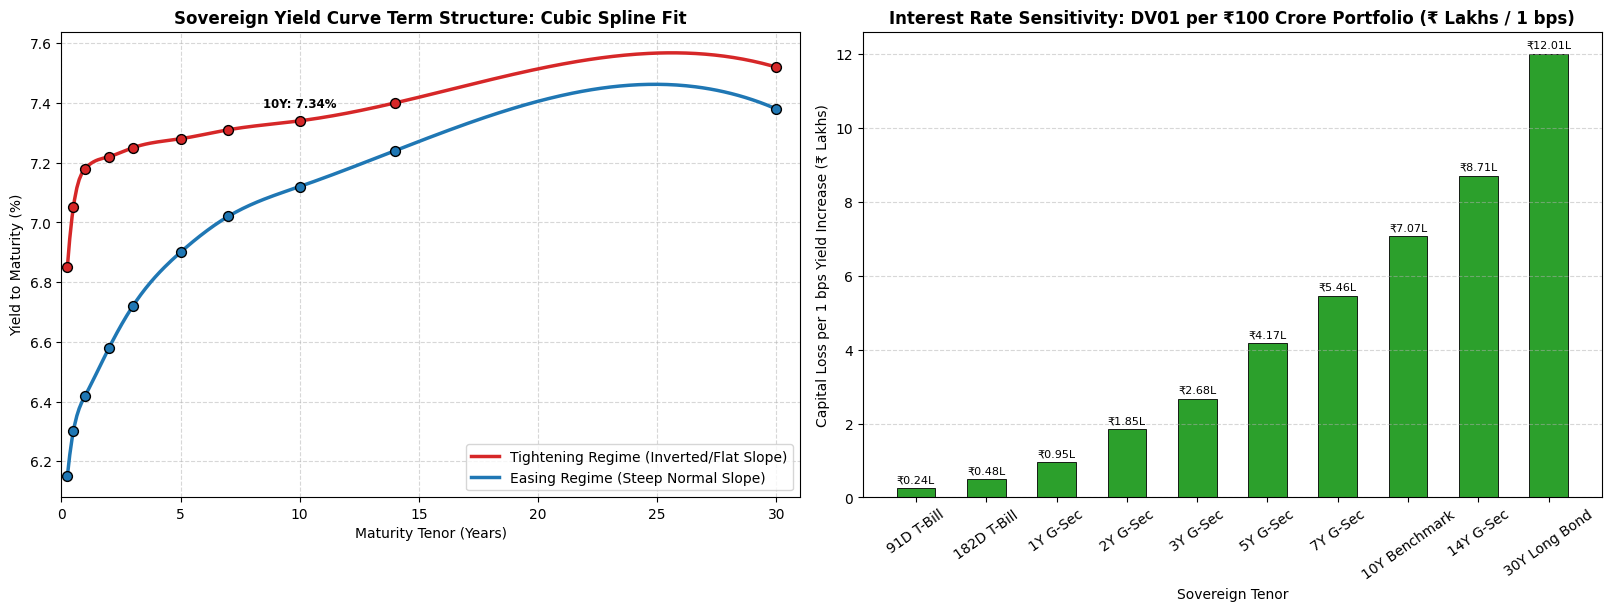

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), layout="constrained")

# --- Chart 1: Continuous Yield Curves (Regime Comparison) ---
ax1.plot(
    dense_tenors,
    curve_tight_dense,
    color="#d62728",
    linewidth=2.5,
    label="Tightening Regime (Inverted/Flat Slope)",
)
ax1.plot(
    dense_tenors,
    curve_easy_dense,
    color="#1f77b4",
    linewidth=2.5,
    label="Easing Regime (Steep Normal Slope)",
)

# Overlay discrete market quote points
ax1.scatter(
    x_tenors,
    y_tight,
    color="#d62728",
    s=50,
    edgecolor="black",
    zorder=5,
)
ax1.scatter(
    x_tenors,
    y_easy,
    color="#1f77b4",
    s=50,
    edgecolor="black",
    zorder=5,
)

ax1.set_title(
    "Sovereign Yield Curve Term Structure: Cubic Spline Fit",
    fontsize=12,
    weight="bold",
)
ax1.set_xlabel("Maturity Tenor (Years)")
ax1.set_ylabel("Yield to Maturity (%)")
ax1.set_xlim(0, 31)
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend(loc="lower right")

# Annotate 10Y Benchmark
y10_tight = df_gsec.loc[
    df_gsec["Tenor_Years"] == 10.0, "Yield_Hiking_Regime_%"
].values[0]
ax1.annotate(
    f"10Y: {y10_tight:.2f}%",
    (10.0, y10_tight),
    textcoords="offset points",
    xytext=(0, 10),
    ha="center",
    fontsize=8.5,
    weight="bold",
)

# --- Chart 2: Portfolio Interest Rate Sensitivity (DV01 across Tenors) ---
bars = ax2.bar(
    df_gsec["Tenor_Label"],
    df_gsec["DV01_per_100Cr_Rupees"] / 1_00_000,  # Express in ₹ Lakhs
    color="#2ca02c",
    edgecolor="black",
    linewidth=0.6,
    width=0.55,
)

ax2.set_title(
    "Interest Rate Sensitivity: DV01 per ₹100 Crore Portfolio (₹ Lakhs / 1 bps)",
    fontsize=12,
    weight="bold",
)
ax2.set_xlabel("Sovereign Tenor")
ax2.set_ylabel("Capital Loss per 1 bps Yield Increase (₹ Lakhs)")
ax2.tick_params(axis="x", rotation=35)
ax2.grid(axis="y", linestyle="--", alpha=0.5)

# Annotate values on top of bars
for bar in bars:
    height = bar.get_height()
    ax2.annotate(
        f"₹{height:.2f}L",
        (bar.get_x() + bar.get_width() / 2, height),
        textcoords="offset points",
        xytext=(0, 4),
        ha="center",
        fontsize=8,
    )

plt.show()